# Kicked Ising with brickwork quantum circuit

### Entanglement: Controlled by the Ising Coupling ($J$)

Looking at the two-qubit block $\hat{U}_{n, n+1}$ the sole non-local operator is the Ising interaction term:
$$\exp\left(-iJ \hat{Z}_n \hat{Z}_{n+1}\right) \equiv R_{ZZ}(2J)$$

Therefore, **$J$ dictates the entanglement dynamics** of the system:
* **Zero Entanglement ($J = 0$):** The system completely decouples into independent, localized single qubits. No entanglement is generated, and initial product states remain product states.
* **Maximal Entanglement Velocity ($J = \pi/4$):** As highlighted in recent literature on quantum chaos (*Bertini et al., "Exact Correlation Functions for Dual-Unitary Lattice Models in 1+1 Dimensions", Physical Review Letters, 2019*), setting $J = \pi/4$ corresponds to the dual-unitary point of the Ising interaction. At this parameter value, the $R_{ZZ}(\pi/2)$ gate becomes locally equivalent to a `CNOT` gate. This creates exactly one perfectly maximally entangling operation, leading to the fastest possible growth of bipartite entanglement entropy.

### Magic: Controlled by the Transverse Kick ($b$) and Longitudinal Field ($h$)

Magic is controlled by the single-qubit rotations, specifically the continuous tuning of the transverse kick $b$ (and potentially the longitudinal field $h$).

* **The Transverse Kick ($b$):** The operator $\exp(-ib\hat{X}) \equiv R_X(2b)$ injects magic into the system whenever $2b$ is not a multiple of $\pi/2$. Tuning $b$ away from Clifford angles generates non-stabilizer states. For example, your default value of $b = 0.4\pi$ (resulting in $R_X(0.8\pi)$) is a strongly non-Clifford operation.
* **The Longitudinal Field ($h$):** The operator $\exp(-ih\hat{Z}) \equiv R_Z(2h)$ also acts as a source of magic depending on its value. If $h = \pi/8$ this corresponds exactly to the $T$-gate.

### Summary of the Resource Regimes

* **Integrable / Free Fermion Point:** If $h = 0$, the 1D transverse-field Ising model can be mapped to free Majorana fermions via the Jordan-Wigner transformation. Even if highly entangled (large $J$), the dynamics are exactly solvable and lack the "magic" required for complex chaotic scrambling.
* **Clifford / Stabilizer Simulator:** If $J = \pi/4$, $h = 0$, and $b = \pi/4$, the entire circuit collapses into the Clifford group. Entanglement grows maximally, but magic is strictly zero, allowing for efficient classical simulation via stabilizer tableaus.
* **Fully Chaotic / Universal Regime:** By setting $J$ to an entangling value (e.g., $J = \pi/4$) and choosing incommensurate, non-Clifford values for $h$ and $b$ (such as $h = \pi/8$ and $b = 0.2\pi$), the circuit simultaneously generates volume-law entanglement and extensive magic. This is the regime of true quantum chaos and represents a classically intractable Floquet thermalization process.

In [ ]:
import numpy as np

def build_circuit_qasm(
    num_qubits: int, 
    num_layers: int, 
    J: float, 
    h: float, 
    b: float
) -> str:
    """
    Generates an OpenQASM 2.0 string for the forward-time Kicked Ising Floquet circuit.
    
    Parameters:
    - num_qubits (int): Total number of qubits in the 1D chain.
    - num_layers (int): Number of Floquet periods (t), where one period is an even+odd layer.
    - J (float): Theoretical Ising coupling strength.
    - h (float): Theoretical longitudinal field strength.
    - b (float): Theoretical transverse kick strength.
    
    Returns:
    - str: Valid OpenQASM 2.0 representation of the circuit.
    """
    if num_qubits < 2:
        raise ValueError("The circuit requires at least 2 qubits.")

    # Standard OpenQASM 2.0 headers
    qasm_lines = [
        "OPENQASM 2.0;",
        'include "qelib1.inc";',
        f"qreg q[{num_qubits}];"
    ]
    
    # Map physical parameters to QASM rotation angles
    theta_J = 2.0 * J
    theta_h = 2.0 * h
    theta_b = 2.0 * b
    
    def apply_u_block(q_n: int, q_n1: int):
        """
        Constructs the symmetric U_{n, n+1} block mapped from Equation (S5).
        q_n corresponds to the bottom wire, q_n1 corresponds to the top wire.
        """
        # 1. RZ(2h) on bottom wire (q_n)
        qasm_lines.append(f"rz({theta_h}) q[{q_n}];")
        
        # 2. RZZ(2J) decomposed into CX - RZ - CX
        qasm_lines.append(f"cx q[{q_n}],q[{q_n1}];")
        qasm_lines.append(f"rz({theta_J}) q[{q_n1}];")
        qasm_lines.append(f"cx q[{q_n}],q[{q_n1}];")
        
        # 3. RX(2b) on both wires
        qasm_lines.append(f"rx({theta_b}) q[{q_n}];")
        qasm_lines.append(f"rx({theta_b}) q[{q_n1}];")
        
        # 4. RZZ(2J) decomposed
        qasm_lines.append(f"cx q[{q_n}],q[{q_n1}];")
        qasm_lines.append(f"rz({theta_J}) q[{q_n1}];")
        qasm_lines.append(f"cx q[{q_n}],q[{q_n1}];")
        
        # 5. RZ(2h) on bottom wire (q_n)
        qasm_lines.append(f"rz({theta_h}) q[{q_n}];")
    
    def apply_external_block(q_n: int, q_n1: int):
        pass

    # Construct the Floquet stroboscopic evolution
    for layer in range(num_layers):
        qasm_lines.append(f"// --- Floquet Period {layer + 1} ---")
        
        # Even sub-layer (\hat{U}_e)
        qasm_lines.append("// Even Layer")
        for i in range(0, num_qubits - 1, 2):
            apply_u_block(i, i + 1)
            
        # Odd sub-layer (\hat{U}_o)
        qasm_lines.append("// Odd Layer")
        for i in range(1, num_qubits - 1, 2):
            apply_u_block(i, i + 1)

    return "\n".join(qasm_lines)

qasm_circuit = build_circuit_qasm(
    num_qubits=6, 
    num_layers=2, 
    J=np.pi/4, 
    h=np.pi/8, 
    b=0.2*np.pi
)

In [ ]:
from qiskit import QuantumCircuit 
circ = QuantumCircuit.from_qasm_str(qasm_circuit)
circ.draw()

┌─────────┐                     ┌──────────┐                     »
q_0: ┤ Rz(π/4) ├──■───────────────■──┤ Rx(2π/5) ├──■───────────────■──»
     └─────────┘┌─┴─┐┌─────────┐┌─┴─┐├──────────┤┌─┴─┐┌─────────┐┌─┴─┐»
q_1: ───────────┤ X ├┤ Rz(π/2) ├┤ X ├┤ Rx(2π/5) ├┤ X ├┤ Rz(π/2) ├┤ X ├»
     ┌─────────┐└───┘└─────────┘└───┘├──────────┤└───┘└─────────┘└───┘»
q_2: ┤ Rz(π/4) ├──■───────────────■──┤ Rx(2π/5) ├──■───────────────■──»
     └─────────┘┌─┴─┐┌─────────┐┌─┴─┐├──────────┤┌─┴─┐┌─────────┐┌─┴─┐»
q_3: ───────────┤ X ├┤ Rz(π/2) ├┤ X ├┤ Rx(2π/5) ├┤ X ├┤ Rz(π/2) ├┤ X ├»
     ┌─────────┐└───┘└─────────┘└───┘├──────────┤└───┘└─────────┘└───┘»
q_4: ┤ Rz(π/4) ├──■───────────────■──┤ Rx(2π/5) ├──■───────────────■──»
     └─────────┘┌─┴─┐┌─────────┐┌─┴─┐├──────────┤┌─┴─┐┌─────────┐┌─┴─┐»
q_5: ───────────┤ X ├┤ Rz(π/2) ├┤ X ├┤ Rx(2π/5) ├┤ X ├┤ Rz(π/2) ├┤ X ├»
                └───┘└─────────┘└───┘└──────────┘└───┘└─────────┘└───┘»
«     ┌─────────┐┌─────────┐                                                 »
«q_0: ┤ Rz(π/4) ├┤ Rz(π/4) ├─────────────────────────────────────────────────»
«     ├─────────┤└─────────┘                ┌──────────┐                     »
«q_1: ┤ Rz(π/4) ├─────■──────────────────■──┤ Rx(2π/5) ├──■───────────────■──»
«     ├─────────┤   ┌─┴─┐   ┌─────────┐┌─┴─┐├──────────┤┌─┴─┐┌─────────┐┌─┴─┐»
«q_2: ┤ Rz(π/4) ├───┤ X ├───┤ Rz(π/2) ├┤ X ├┤ Rx(2π/5) ├┤ X ├┤ Rz(π/2) ├┤ X ├»
«     ├─────────┤   └───┘   └─────────┘└───┘├──────────┤└───┘└─────────┘└───┘»
«q_3: ┤ Rz(π/4) ├─────■──────────────────■──┤ Rx(2π/5) ├──■───────────────■──»
«     ├─────────┤   ┌─┴─┐   ┌─────────┐┌─┴─┐├──────────┤┌─┴─┐┌─────────┐┌─┴─┐»
«q_4: ┤ Rz(π/4) ├───┤ X ├───┤ Rz(π/2) ├┤ X ├┤ Rx(2π/5) ├┤ X ├┤ Rz(π/2) ├┤ X ├»
«     └─────────┘   └───┘   └─────────┘└───┘└──────────┘└───┘└─────────┘└───┘»
«q_5: ───────────────────────────────────────────────────────────────────────»
«                                                                            »
«                                     ┌──────────┐                     »
«q_0: ─────────────■───────────────■──┤ Rx(2π/5) ├──■───────────────■──»
«     ┌─────────┐┌─┴─┐┌─────────┐┌─┴─┐├──────────┤┌─┴─┐┌─────────┐┌─┴─┐»
«q_1: ┤ Rz(π/4) ├┤ X ├┤ Rz(π/2) ├┤ X ├┤ Rx(2π/5) ├┤ X ├┤ Rz(π/2) ├┤ X ├»
«     ├─────────┤└───┘└─────────┘└───┘├──────────┤└───┘└─────────┘└───┘»
«q_2: ┤ Rz(π/4) ├──■───────────────■──┤ Rx(2π/5) ├──■───────────────■──»
«     ├─────────┤┌─┴─┐┌─────────┐┌─┴─┐├──────────┤┌─┴─┐┌─────────┐┌─┴─┐»
«q_3: ┤ Rz(π/4) ├┤ X ├┤ Rz(π/2) ├┤ X ├┤ Rx(2π/5) ├┤ X ├┤ Rz(π/2) ├┤ X ├»
«     ├─────────┤└───┘└─────────┘└───┘├──────────┤└───┘└─────────┘└───┘»
«q_4: ┤ Rz(π/4) ├──■───────────────■──┤ Rx(2π/5) ├──■───────────────■──»
«     └─────────┘┌─┴─┐┌─────────┐┌─┴─┐├──────────┤┌─┴─┐┌─────────┐┌─┴─┐»
«q_5: ───────────┤ X ├┤ Rz(π/2) ├┤ X ├┤ Rx(2π/5) ├┤ X ├┤ Rz(π/2) ├┤ X ├»
«                └───┘└─────────┘└───┘└──────────┘└───┘└─────────┘└───┘»
«     ┌─────────┐                                                      »
«q_0: ┤ Rz(π/4) ├──────────────────────────────────────────────────────»
«     ├─────────┤                     ┌──────────┐                     »
«q_1: ┤ Rz(π/4) ├──■───────────────■──┤ Rx(2π/5) ├──■───────────────■──»
«     ├─────────┤┌─┴─┐┌─────────┐┌─┴─┐├──────────┤┌─┴─┐┌─────────┐┌─┴─┐»
«q_2: ┤ Rz(π/4) ├┤ X ├┤ Rz(π/2) ├┤ X ├┤ Rx(2π/5) ├┤ X ├┤ Rz(π/2) ├┤ X ├»
«     ├─────────┤└───┘└─────────┘└───┘├──────────┤└───┘└─────────┘└───┘»
«q_3: ┤ Rz(π/4) ├──■───────────────■──┤ Rx(2π/5) ├──■───────────────■──»
«     ├─────────┤┌─┴─┐┌─────────┐┌─┴─┐├──────────┤┌─┴─┐┌─────────┐┌─┴─┐»
«q_4: ┤ Rz(π/4) ├┤ X ├┤ Rz(π/2) ├┤ X ├┤ Rx(2π/5) ├┤ X ├┤ Rz(π/2) ├┤ X ├»
«     └─────────┘└───┘└─────────┘└───┘└──────────┘└───┘└─────────┘└───┘»
«q_5: ─────────────────────────────────────────────────────────────────»
«                                                                      »
«                
«q_0: ───────────
«     ┌─────────┐
«q_1: ┤ Rz(π/4) ├
«     └─────────┘
«q_2: ───────────
«     ┌─────────┐
«q_3: ┤ Rz(π/4) ├


In [ ]:
from qibo.models import Circuit
circ = Circuit.from_qasm(qasm_circuit)
circ.draw()

'q0:     ─RZ─o────o─RX─o────o─RZ─────────────────────────────────────────────── ...\nq1:     ────X─RZ─X─RX─X─RZ─X─────────────────────────────────────────RZ─o────o ...\nq2:     ─────────────────────RZ─o────o─RX─o────o─RZ─────────────────────X─RZ─X ...\nq3:     ────────────────────────X─RZ─X─RX─X─RZ─X────────────────────────────── ...\nq4:     ─────────────────────────────────────────RZ─o────o─RX─o────o─RZ─────── ...\nq5:     ────────────────────────────────────────────X─RZ─X─RX─X─RZ─X────────── ...\n\nq0: ... ───────────────────────────────RZ─o────o─RX─o────o─RZ───────────────── ...\nq1: ... ─RX─o────o─RZ─────────────────────X─RZ─X─RX─X─RZ─X──────────────────── ...\nq2: ... ─RX─X─RZ─X─────────────────────────────────────────RZ─o────o─RX─o────o ...\nq3: ... ───────────RZ─o────o─RX─o────o─RZ─────────────────────X─RZ─X─RX─X─RZ─X ...\nq4: ... ──────────────X─RZ─X─RX─X─RZ─X──────────────────────────────────────── ...\nq5: ... ─────────────────────────────────────────────────────────────────

(<Figure size 1666.67x100 with 1 Axes>, <Axes: >)

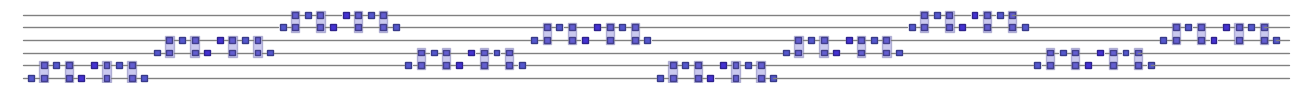

In [ ]:
import quimb.tensor as qtn
circ = qtn.Circuit.from_openqasm2_str(qasm_circuit)
circ.draw()

In [ ]:
import numpy as np
from typing import Tuple, List

def define_square_lattice(rows: int, cols: int) -> Tuple[int, List[Tuple[int, int]]]:
    """
    Defines the spatial topology of a 2D square lattice.
    
    Parameters:
    - rows (int): Number of rows in the lattice.
    - cols (int): Number of columns in the lattice.
    
    Returns:
    - num_qubits (int): Total number of vertices (qubits) in the graph V.
    - edges (List[Tuple[int, int]]): List of interacting qubit pairs in E.
    """
    num_qubits = rows * cols
    edges = []
    
    for r in range(rows):
        for c in range(cols):
            i = r * cols + c
            # Horizontal nearest-neighbor coupling
            if c < cols - 1:
                edges.append((i, i + 1))
            # Vertical nearest-neighbor coupling
            if r < rows - 1:
                edges.append((i, i + cols))
                
    return num_qubits, edges

In [ ]:
def build_2d_circuit_qasm(
    num_qubits: int, 
    edges: List[Tuple[int, int]], 
    num_layers: int, 
    J: float, 
    h: float, 
    b: float
) -> str:
    """
    Implements Floquet dynamics on an arbitrary graph and transposes it to OpenQASM 2.0.
    
    Parameters:
    - num_qubits (int): Size of the vertex set V.
    - edges (List[Tuple[int, int]]): Interacting edges E.
    - num_layers (int): Number of Floquet periods to simulate.
    - J (float): Ising coupling strength.
    - h (float): Longitudinal field strength.
    - b (float): Transverse kick strength.
    
    Returns:
    - str: Valid OpenQASM 2.0 representation of the system.
    """
    # Initialize OpenQASM 2.0 architecture
    qasm_lines = [
        "OPENQASM 2.0;",
        'include "qelib1.inc";',
        f"qreg q[{num_qubits}];"
    ]
    
    # Map physical parameters to rotation angles
    theta_J = 2.0 * J
    theta_h = 2.0 * h
    theta_b = 2.0 * b

    # Construct the stroboscopic evolution operator
    for layer in range(num_layers):
        qasm_lines.append(f"\n// --- Floquet Period {layer + 1} ---")
        
        # 1. Local Longitudinal Field (Commuting Z-rotations)
        qasm_lines.append("// Longitudinal Field Layer")
        if h != 0.0:
            for i in range(num_qubits):
                qasm_lines.append(f"rz({theta_h}) q[{i}];")

        # 2. Entangling Ising Coupling (Commuting ZZ-rotations)
        qasm_lines.append("// Ising Interaction Layer")
        if J != 0.0:
            for node1, node2 in edges:
                # Decompose RZZ into native CX and RZ gates
                qasm_lines.append(f"cx q[{node1}],q[{node2}];")
                qasm_lines.append(f"rz({theta_J}) q[{node2}];")
                qasm_lines.append(f"cx q[{node1}],q[{node2}];")

        # 3. Transverse Kick (Non-commuting X-rotations)
        qasm_lines.append("// Transverse Kick Layer")
        if b != 0.0:
            for i in range(num_qubits):
                qasm_lines.append(f"rx({theta_b}) q[{i}];")

    return "\n".join(qasm_lines)